In [2]:
# import libraries
import os
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("youssefsalahzakria/fruit-and-vegetables-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/fruit-and-vegetables-classification


In [4]:
# Paths

# DATA_DIR = "dataset"
DATA_DIR = path

MODEL_PATH = "models/ingredient_model.h5"

IMG_SIZE = (224, 224)
BATCH_SIZE = 64
EPOCH_PHASE_1 = 25
EPOCH_PHASE_2 = 15

In [5]:
# Datagen preparation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,         
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    brightness_range=(0.9, 1.1),
    horizontal_flip=True,
    fill_mode='nearest'
)

# Add validation and test datagen
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


train_gen = train_datagen.flow_from_directory(
    DATA_DIR + "/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR + "/validation",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    DATA_DIR + "/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 46187 images belonging to 50 classes.
Found 12544 images belonging to 50 classes.
Found 13353 images belonging to 50 classes.


In [6]:
# print class names
if os.path.isdir("/kaggle/input/fruit-and-vegetables-classification/train"):
    CLASS_NAMES = sorted(os.listdir("/kaggle/input/fruit-and-vegetables-classification/train"))

print(CLASS_NAMES)

['Apple', 'Avocado', 'Banana', 'Beetroot', 'Blackberry', 'Blueberry', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Chilli Peper', 'Corn', 'Cucumber', 'Dates', 'Dragonfruit', 'Eggplant', 'Fig', 'Garlic', 'Ginger', 'Grapes', 'Guava', 'Jalepeno', 'Kiwi', 'Lemon', 'Lettuce', 'Mango', 'Mushroom', 'Okra', 'Olive', 'Onion', 'Orange', 'Paprika', 'Peanuts', 'Pear', 'Peas', 'Pineapple', 'Pomegranate', 'Potato', 'Pumpkin', 'Raddish', 'Rambutan', 'Soy Beans', 'Spinach', 'Strawberry', 'Sweetcorn', 'Sweetpotato', 'Tomato', 'Turnip', 'Watermelon']


In [6]:
# Model compilation

base_model = MobileNetV2(include_top=False, input_shape=IMG_SIZE + (3,), weights="imagenet")
base_model.trainable = False  # freeze for fast training

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(train_gen.num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

I0000 00:00:1765146148.640639      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
# add earlystoping callbacks
Callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
    ModelCheckpoint(MODEL_PATH, save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.25, patience=3, verbose=1)
]

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,603,890 (9.93 MB)

 Trainable params: 343,346 (1.31 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

None


In [8]:
# First phase: train top layers only
print("\n Phase 1: Training top layers only...")
history_1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCH_PHASE_1,
    callbacks=Callbacks
)

# save model
os.makedirs("models", exist_ok=True)
model.save(MODEL_PATH)
print(f"Model saved after Phase 1.")



 Phase 1: Training top layers only...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


I0000 00:00:1765146163.596403     127 service.cc:148] XLA service 0x7d683c005740 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765146163.598014     127 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1765146164.647305     127 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/722 ━━━━━━━━━━━━━━━━━━━━ 2:39:01 13s/step - accuracy: 0.0625 - loss: 4.8593

...

722/722 ━━━━━━━━━━━━━━━━━━━━ 723s 1s/step - accuracy: 0.8685 - loss: 0.4099 - val_accuracy: 0.8712 - val_loss: 0.5455 - learning_rate: 0.0010
Epoch 17/25
722/722 ━━━━━━━━━━━━━━━━━━━━ 728s 1s/step - accuracy: 0.8778 - loss: 0.3873 - val_accuracy: 0.8703 - val_loss: 0.5422 - learning_rate: 0.0010
Epoch 18/25
722/722 ━━━━━━━━━━━━━━━━━━━━ 717s 993ms/step - accuracy: 0.8770 - loss: 0.3881 - val_accuracy: 0.8666 - val_loss: 0.5620 - learning_rate: 0.0010
Epoch 19/25
722/722 ━━━━━━━━━━━━━━━━━━━━ 0s 946ms/step - accuracy: 0.8806 - loss: 0.3736
Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
722/722 ━━━━━━━━━━━━━━━━━━━━ 723s 1s/step - accuracy: 0.8806 - loss: 0.3737 - val_accuracy: 0.8654 - val_loss: 0.5697 - learning_rate: 0.0010
Epoch 20/25
722/722 ━━━━━━━━━━━━━━━━━━━━ 0s 932ms/step - accuracy: 0.8885 - loss: 0.3470

722/722 ━━━━━━━━━━━━━━━━━━━━ 716s 992ms/step - accuracy: 0.8885 - loss: 0.3470 - val_accuracy: 0.8752 - val_loss: 0.5378 - learning_rate: 2.5000e-04
Epoch 21/25
722/722 ━━━━━━━━━━━━━━━━━━━━ 718s 994ms/step - accuracy: 0.8996 - loss: 0.3130 - val_accuracy: 0.8735 - val_loss: 0.5445 - learning_rate: 2.5000e-04
Epoch 22/25
722/722 ━━━━━━━━━━━━━━━━━━━━ 0s 977ms/step - accuracy: 0.9030 - loss: 0.2989

722/722 ━━━━━━━━━━━━━━━━━━━━ 746s 1s/step - accuracy: 0.9030 - loss: 0.2989 - val_accuracy: 0.8790 - val_loss: 0.5268 - learning_rate: 2.5000e-04
Epoch 23/25
722/722 ━━━━━━━━━━━━━━━━━━━━ 743s 1s/step - accuracy: 0.9051 - loss: 0.2930 - val_accuracy: 0.8778 - val_loss: 0.5348 - learning_rate: 2.5000e-04
Epoch 24/25
722/722 ━━━━━━━━━━━━━━━━━━━━ 723s 1s/step - accuracy: 0.9033 - loss: 0.2931 - val_accuracy: 0.8784 - val_loss: 0.5298 - learning_rate: 2.5000e-04
Epoch 25/25
722/722 ━━━━━━━━━━━━━━━━━━━━ 0s 961ms/step - accuracy: 0.9122 - loss: 0.2747

722/722 ━━━━━━━━━━━━━━━━━━━━ 735s 1s/step - accuracy: 0.9122 - loss: 0.2747 - val_accuracy: 0.8812 - val_loss: 0.5336 - learning_rate: 2.5000e-04


Model saved after Phase 1.


In [11]:
# Second phase: fine-tuning

# unfreeze last few layers
fine_tune_layers = int(len(base_model.layers) * 0.75)  # unfreeze last 25%
for layer in base_model.layers[:fine_tune_layers]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_layers:]:
    layer.trainable = True


# recompile with a lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5), 
    loss="categorical_crossentropy", 
    metrics=["accuracy"]
    )


In [12]:
print("\n Phase 2: Fine-tuning last layers of MobileNetV2...")
history_2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCH_PHASE_2,
    callbacks=Callbacks
)


# Save final model
model.save(MODEL_PATH.replace(".h5", "_final.h5"))
print(f"Final fine-tuned model saved after Phase 2.")


 Phase 2: Fine-tuning last layers of MobileNetV2...
Epoch 1/15


E0000 00:00:1765164596.357081     129 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1765164596.555509     129 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


205/722 ━━━━━━━━━━━━━━━━━━━━ 8:12 953ms/step - accuracy: 0.7589 - loss: 0.8262

E0000 00:00:1765164798.306275     127 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1765164798.505745     127 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


722/722 ━━━━━━━━━━━━━━━━━━━━ 750s 1s/step - accuracy: 0.7809 - loss: 0.7469 - val_accuracy: 0.8725 - val_loss: 0.5840 - learning_rate: 1.0000e-05
Epoch 2/15
722/722 ━━━━━━━━━━━━━━━━━━━━ 754s 1s/step - accuracy: 0.8465 - loss: 0.4990 - val_accuracy: 0.8732 - val_loss: 0.5662 - learning_rate: 1.0000e-05
Epoch 3/15
722/722 ━━━━━━━━━━━━━━━━━━━━ 710s 983ms/step - accuracy: 0.8650 - loss: 0.4433 - val_accuracy: 0.8701 - val_loss: 0.5694 - learning_rate: 1.0000e-05
Epoch 4/15
722/722 ━━━━━━━━━━━━━━━━━━━━ 776s 1s/step - accuracy: 0.8764 - loss: 0.3973 - val_accuracy: 0.8717 - val_loss: 0.5683 - learning_rate: 1.0000e-05
Epoch 5/15
722/722 ━━━━━━━━━━━━━━━━━━━━ 730s 1s/step - accuracy: 0.8870 - loss: 0.3620 - val_accuracy: 0.8742 - val_loss: 0.5632 - learning_rate: 1.0000e-05
Epoch 6/15
722/722 ━━━━━━━━━━━━━━━━━━━━ 720s 997ms/step - accuracy: 0.8954 - loss: 0.3272 - val_accuracy: 0.8774 - val_loss: 0.5497 - learning_rate: 1.0000e-05
Epoch 7/15
722/722 ━━━━━━━━━━━━━━━━━━━━ 733s 1s/step - accuracy

...

722/722 ━━━━━━━━━━━━━━━━━━━━ 706s 977ms/step - accuracy: 0.9063 - loss: 0.2911 - val_accuracy: 0.8816 - val_loss: 0.5257 - learning_rate: 1.0000e-05
Epoch 10/15
722/722 ━━━━━━━━━━━━━━━━━━━━ 0s 958ms/step - accuracy: 0.9121 - loss: 0.2751

722/722 ━━━━━━━━━━━━━━━━━━━━ 736s 1s/step - accuracy: 0.9121 - loss: 0.2751 - val_accuracy: 0.8866 - val_loss: 0.5245 - learning_rate: 1.0000e-05
Epoch 11/15
722/722 ━━━━━━━━━━━━━━━━━━━━ 766s 1s/step - accuracy: 0.9161 - loss: 0.2587 - val_accuracy: 0.8864 - val_loss: 0.5145 - learning_rate: 1.0000e-05
Epoch 12/15
722/722 ━━━━━━━━━━━━━━━━━━━━ 0s 973ms/step - accuracy: 0.9202 - loss: 0.2472

722/722 ━━━━━━━━━━━━━━━━━━━━ 760s 1s/step - accuracy: 0.9202 - loss: 0.2472 - val_accuracy: 0.8897 - val_loss: 0.5065 - learning_rate: 1.0000e-05
Epoch 13/15
722/722 ━━━━━━━━━━━━━━━━━━━━ 732s 1s/step - accuracy: 0.9221 - loss: 0.2402 - val_accuracy: 0.8878 - val_loss: 0.5058 - learning_rate: 1.0000e-05
Epoch 14/15
722/722 ━━━━━━━━━━━━━━━━━━━━ 727s 1s/step - accuracy: 0.9256 - loss: 0.2266 - val_accuracy: 0.8892 - val_loss: 0.5080 - learning_rate: 1.0000e-05
Epoch 15/15
722/722 ━━━━━━━━━━━━━━━━━━━━ 0s 969ms/step - accuracy: 0.9287 - loss: 0.2209

722/722 ━━━━━━━━━━━━━━━━━━━━ 743s 1s/step - accuracy: 0.9287 - loss: 0.2209 - val_accuracy: 0.8925 - val_loss: 0.4998 - learning_rate: 1.0000e-05


Final fine-tuned model saved after Phase 2.


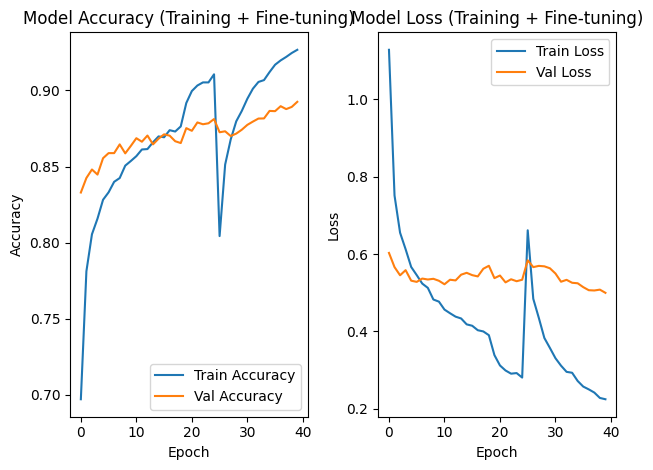

In [14]:
# Plot training history

acc = history_1.history['accuracy'] + history_2.history['accuracy']
val_acc = history_1.history['val_accuracy'] + history_2.history['val_accuracy']
loss = history_1.history['loss'] + history_2.history['loss']
val_loss = history_1.history['val_loss'] + history_2.history['val_loss']

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title('Model Accuracy (Training + Fine-tuning)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('Model Loss (Training + Fine-tuning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

